# Energy-Efficient & Carbon-Aware Cloud Task Scheduling
**Navaneetha Thalakokkula — MSc Cloud Computing, National College of Ireland**

A host-capacity simulation on the **real Google Cluster Trace 2011** and **real UK grid-carbon data**,
comparing three baselines (**FIFO/Round-Robin, Energy-aware consolidation, Carbon-aware greedy**) and six
metaheuristics (**WOA, GWO, PSO, DE, HHO, GA**) plus **CA-WOA** — a Carbon-Aware enhanced Whale Optimization
Algorithm — on energy, carbon, cost, SLA, utilisation and makespan.

**Platform:** Python · Mealpy · NumPy · pandas · Matplotlib.

## 1. Setup

In [1]:
import json, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from mealpy import FloatVar, WOA, GWO, PSO, DE, HHO, GA
ROOT = "/home/durga/carbon-aware-scheduler"
SEED = 42; np.random.seed(SEED); rng = np.random.default_rng(SEED)
print("Mealpy ready.")

Mealpy ready.


## 2. Energy model with servers (hosts)
A switched-on server draws idle power even when nearly empty, so energy depends on **active servers**:
$$ E_{slot} = \big(\text{active\_hosts}\cdot P_{idle} + (P_{max}-P_{idle})\cdot load\big)\cdot \Delta t. $$
Host capacity `C = 1.0` = one normalised machine (Google `cpu_request` is a fraction of the largest machine).

In [2]:
P_IDLE_W, P_MAX_W, SLOT_H, C = 100.0, 250.0, 0.5, 1.0

## 3. Real carbon intensity and cost
$$ CO_2 = \sum_{slot} E_{slot}\cdot CI_{slot}, \qquad Cost = \sum_{slot} E_{slot}\cdot price_{slot}. $$

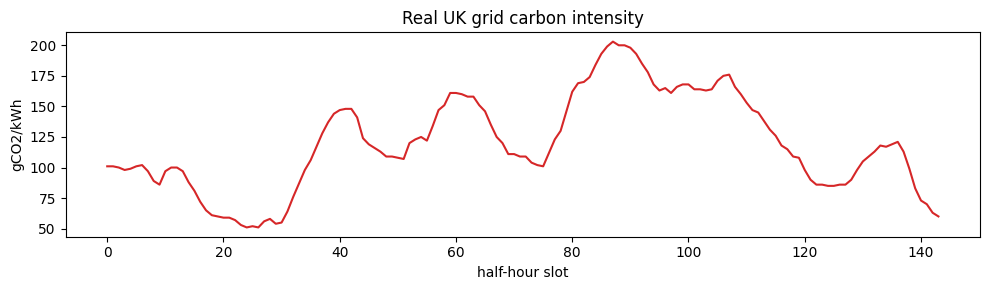

In [3]:
with open(ROOT + "/data/carbon/3day_window.json") as f:
    j = json.load(f)
CI = np.array([r["intensity"].get("actual") or r["intensity"].get("forecast") for r in j["data"]], float)
PRICE = np.full(len(CI), 0.15)
for day in range(len(CI)//48 + 1):
    for s in range(32, 40):
        k = day*48 + s
        if k < len(PRICE): PRICE[k] = 0.30
H = len(CI)
plt.figure(figsize=(10, 3)); plt.plot(CI, color="tab:red")
plt.title("Real UK grid carbon intensity"); plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh")
plt.tight_layout(); plt.show()

## 4. Real workload — Google Cluster Trace 2011

In [4]:
cols = ["time","missing","job_id","task_index","machine_id","event_type","user","sched_class",
        "priority","cpu_request","mem_request","disk_request","constraint"]
df = pd.read_csv(ROOT + "/data/workload/google_task_events_part0.csv.gz", header=None, names=cols)
sub = (df[df.event_type==0][["job_id","task_index","time","cpu_request"]].dropna(subset=["cpu_request"])
       .rename(columns={"time":"submit"}).groupby(["job_id","task_index"], as_index=False).first())
end = (df[df.event_type.isin([2,3,4,5])][["job_id","task_index","time"]]
       .rename(columns={"time":"end"}).groupby(["job_id","task_index"], as_index=False).first())
m = sub.merge(end, on=["job_id","task_index"]); m["dur_us"] = m["end"] - m["submit"]
m = m[(m.dur_us>0) & (m.cpu_request>0)].reset_index(drop=True).head(60)
smin, smax = m.submit.min(), m.submit.max()
tasks = []
for _, r in m.iterrows():
    dur = int(np.clip(math.ceil(r.dur_us/1.8e9),1,12)); u = round(float(np.clip(r.cpu_request,0.05,1.0)),3)
    e = int((r.submit-smin)/(smax-smin+1)*(H//3)); tasks.append({"dur":dur,"u":u,"earliest":e,"deadline":e+dur+8})
N = len(tasks)
pd.DataFrame(tasks).head(6)

,dur,u,earliest,deadline
0,1,0.062,0,9
1,4,0.222,0,12
2,4,0.159,0,12
3,1,0.159,0,9
4,2,0.116,0,10
5,4,0.116,0,12


## 5. Host count (derived) + metrics
`M = ceil(peak per-slot demand under FIFO)` — minimum servers to run the baseline.
Metrics: carbon, energy, cost, **SLA**, **utilisation**, **makespan**, capacity **overload**.

In [5]:
MAX_DEFER = 24
def slot_loads(starts):
    load, count = {}, {}
    for t, s in zip(tasks, starts):
        for k in range(s, s+t["dur"]):
            if k < H: load[k] = load.get(k,0.0)+t["u"]; count[k] = count.get(k,0)+1
    return load, count
fifo_starts = [t["earliest"] for t in tasks]
M = math.ceil(max(slot_loads(fifo_starts)[0].values()))
print("Derived host count M =", M, "(capacity C =", C, "each)")
def evaluate(starts, consolidate=True):
    load, count = slot_loads(starts)
    carbon_g = cost = energy = overload = total = 0.0; util = []
    viol = sum(1 for t, s in zip(tasks, starts) if s + t["dur"] > t["deadline"])
    makespan = max((s + t["dur"]) for t, s in zip(tasks, starts))
    for k, ld in load.items():
        active = count[k] if not consolidate else max(1, math.ceil(ld / C))
        p = active*P_IDLE_W + (P_MAX_W-P_IDLE_W)*ld
        energy += p*SLOT_H/1000.0; carbon_g += p*SLOT_H/1000.0*CI[k]; cost += p*SLOT_H/1000.0*PRICE[k]
        util.append(ld/(active*C)); overload += max(0.0, ld-M); total += ld
    return {"Carbon_kgCO2": carbon_g/1000.0, "Energy_kWh": energy, "Cost_GBP": cost,
            "SLA_%": 100.0*viol/N, "Util_%": 100.0*np.mean(util) if util else 0.0,
            "Makespan_h": makespan*SLOT_H, "Overload_%": 100.0*overload/total if total else 0.0}
def decode(x):
    out = []
    for xi, t in zip(x, tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        out.append(t["earliest"] + int(round(xi*room)))
    return out

Derived host count M = 5 (capacity C = 1.0 each)


## 6. Baselines + carbon-aware scheduling
$$ F = \frac{CO_2}{CO_2^{base}} + 3\cdot\frac{SLAV}{100} + 3\cdot\frac{overload}{100}. $$

In [6]:
base = evaluate(fifo_starts, consolidate=False)
def cred(mm): return (base["Carbon_kgCO2"]-mm["Carbon_kgCO2"])/base["Carbon_kgCO2"]*100.0
def fitness(x):
    mm = evaluate(decode(x), consolidate=True)
    return (mm["Carbon_kgCO2"]/base["Carbon_kgCO2"]) + 3.0*(mm["SLA_%"]/100.0) + 3.0*(mm["Overload_%"]/100.0)
def run(model, starting=None):
    p = {"obj_func": fitness, "bounds": FloatVar(lb=[0.0]*N, ub=[1.0]*N), "minmax":"min", "log_to": None}
    g = model.solve(p, starting_solutions=starting, seed=SEED)
    return evaluate(decode(g.solution), consolidate=True)
def greedy_carbon_starts():
    out = []
    for t in tasks:
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        hi = max(0, min(room, t["deadline"] - t["dur"] - t["earliest"])); bo, bc = 0, float("inf")
        for o in range(0, hi+1):
            c = sum(CI[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < H)
            if c < bc: bc, bo = c, o
        out.append(t["earliest"]+bo)
    return out
results = {"FIFO/Round-Robin (baseline)": base,
           "Energy-aware (consolidation)": evaluate(fifo_starts, consolidate=True),
           "Carbon-aware greedy": evaluate(greedy_carbon_starts(), consolidate=True)}
for name, cls in [("WOA",WOA.OriginalWOA),("GWO",GWO.OriginalGWO),("PSO",PSO.OriginalPSO),
                  ("DE",DE.OriginalDE),("HHO",HHO.OriginalHHO),("GA",GA.OriginalGA)]:
    results[name] = run(cls(epoch=120, pop_size=40)); print("ran", name)

ran WOA


ran GWO


ran PSO


ran DE


ran HHO
ran GA


## 7. CA-WOA — Carbon-Aware Whale Optimization
Seeds part of WOA's population with a carbon-aware guess (each job near its lowest-carbon feasible slot),
then optimises under the capacity constraint.

In [7]:
def greedy_x():
    return np.clip(np.array([(s-t["earliest"])/max(1, min(MAX_DEFER, H-t["dur"]-t["earliest"]))
                             for s, t in zip(greedy_carbon_starts(), tasks)]), 0, 1)
def carbon_aware_seeds(pop):
    g = greedy_x(); seeds = [g.copy()]
    for _ in range(pop//3): seeds.append(np.clip(g + rng.normal(0,0.10,N), 0, 1))
    while len(seeds) < pop: seeds.append(rng.uniform(0,1,N))
    return np.array(seeds[:pop])
results["CA-WOA"] = run(WOA.OriginalWOA(epoch=120, pop_size=40), starting=carbon_aware_seeds(40))
print("CA-WOA:", results["CA-WOA"])

CA-WOA: {'Carbon_kgCO2': 0.08399514999999998, 'Energy_kWh': 0.9325749999999997, 'Cost_GBP': 0.13988624999999993, 'SLA_%': 0.0, 'Util_%': 82.1, 'Makespan_h': 5.5, 'Overload_%': 0.0}


## 8. Comparison — all methods, all metrics

In [8]:
dfres = pd.DataFrame(results).T
dfres["CarbonReduction_%"] = [round(cred(results[i]),2) for i in dfres.index]
dfres.loc["FIFO/Round-Robin (baseline)", "CarbonReduction_%"] = 0.0
dfres = dfres[["CarbonReduction_%","SLA_%","Overload_%","Energy_kWh","Util_%","Makespan_h"]].round(2)
dfres

,CarbonReduction_%,SLA_%,Overload_%,Energy_kWh,Util_%,Makespan_h
FIFO/Round-Robin (baseline),0.00,0.00,0.0,5.03,10.00,2.0
Energy-aware (consolidation),80.51,0.00,0.0,0.98,75.13,2.0
Carbon-aware greedy,82.57,0.00,0.0,0.98,75.13,5.5
WOA,81.51,0.00,0.0,0.93,86.45,2.0
GWO,80.62,0.00,0.0,0.98,77.46,4.0
PSO,74.97,15.00,0.0,1.38,40.31,10.0
DE,72.91,23.33,0.0,1.63,32.28,12.5
HHO,81.59,0.00,0.0,0.93,83.52,2.5
GA,70.54,48.33,0.0,1.73,29.59,12.0
CA-WOA,83.44,0.00,0.0,0.93,82.10,5.5


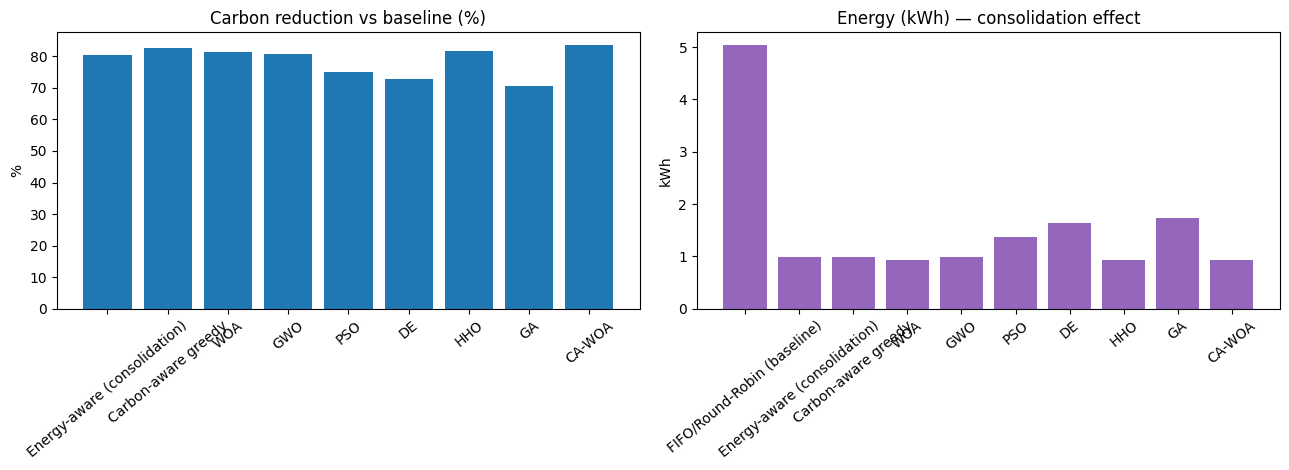

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
o = [i for i in dfres.index if i != "FIFO/Round-Robin (baseline)"]
ax[0].bar(o, dfres.loc[o,"CarbonReduction_%"], color="tab:blue"); ax[0].set(title="Carbon reduction vs baseline (%)", ylabel="%"); ax[0].tick_params(axis="x", rotation=40)
ax[1].bar(dfres.index, dfres["Energy_kWh"], color="tab:purple"); ax[1].set(title="Energy (kWh) — consolidation effect", ylabel="kWh"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 9. LSTM carbon forecasting (reactive → predictive)
Train an **LSTM** on ~111 days of real UK carbon history to **predict future carbon intensity**, so the
scheduler can plan toward *forecasted* clean windows. Accuracy is reported on **held-out (unseen)** data.

2026-07-05 23:23:45.586656: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-05 23:23:45.603875: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/home/durga/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Training LSTM (~1 min)...


LSTM forecast MAE on UNSEEN data: 3.79 gCO2/kWh


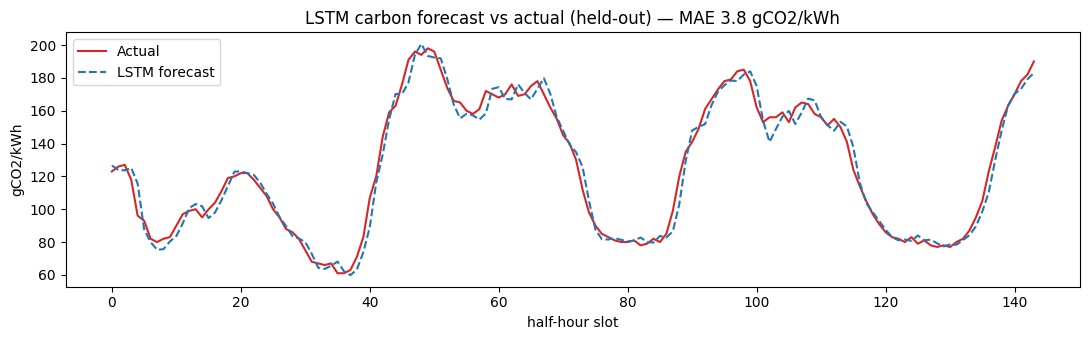

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
tf.random.set_seed(SEED)
hist = pd.read_csv(ROOT + "/data/carbon/carbon_history.csv")["intensity"].astype(float).values
LOOK_BACK = 48
nte = int(len(hist)*0.2); tr, te = hist[:-nte], hist[-nte:]
flo, fhi = tr.min(), tr.max(); fsc = lambda a:(a-flo)/(fhi-flo); fiv = lambda a:a*(fhi-flo)+flo
def fwin(a):
    return (np.array([a[i:i+LOOK_BACK] for i in range(len(a)-LOOK_BACK)])[...,None],
            np.array([a[i+LOOK_BACK] for i in range(len(a)-LOOK_BACK)]))
Xtr, ytr = fwin(fsc(tr)); fctx = fsc(np.concatenate([tr[-LOOK_BACK:], te])); Xte, yte = fwin(fctx)
fmodel = Sequential([Input((LOOK_BACK,1)), LSTM(32), Dense(1)]); fmodel.compile("adam", "mse")
print("Training LSTM (~1 min)..."); fmodel.fit(Xtr, ytr, epochs=20, batch_size=32, verbose=0)
fpred = fiv(fmodel.predict(Xte, verbose=0).ravel()); ftrue = fiv(yte)
fmae = float(np.mean(np.abs(fpred-ftrue))); print("LSTM forecast MAE on UNSEEN data: %.2f gCO2/kWh" % fmae)
plt.figure(figsize=(11,3.5)); plt.plot(ftrue[:144], label="Actual", color="tab:red")
plt.plot(fpred[:144], "--", label="LSTM forecast", color="tab:blue")
plt.title("LSTM carbon forecast vs actual (held-out) — MAE %.1f gCO2/kWh" % fmae)
plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh"); plt.legend(); plt.tight_layout(); plt.show()

## 10. Forecast-driven vs reactive vs oracle scheduling
Schedule the jobs three ways, each scored on the **actual** carbon: **Reactive** (run at earliest),
**Forecast** (shift toward LSTM-predicted clean slots), **Oracle** (perfect foresight = upper bound).

Reactive 0.8306 | Forecast(LSTM) 0.7951 | Oracle 0.7850  kg CO2
Forecast-driven captures 78% of the oracle's possible saving


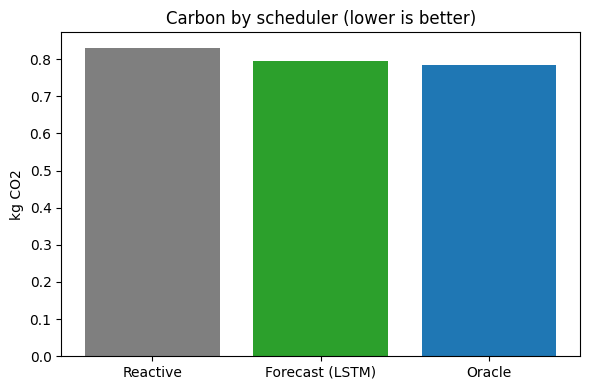

In [11]:
CI_act = ftrue[-144:]; CI_for = fpred[-144:]; FH = len(CI_act)
def fe(u): return (P_IDLE_W + (P_MAX_W-P_IDLE_W)*u)*SLOT_H/1000.0
def real_carbon(starts):
    return sum(fe(t["u"])*CI_act[k] for t, s in zip(tasks, starts)
               for k in range(s, s+t["dur"]) if k < FH)/1000.0
def fgreedy(CIv):
    out = []
    for t in tasks:
        hio = max(0, min(MAX_DEFER, FH-t["dur"]-t["earliest"], t["deadline"]-t["dur"]-t["earliest"]))
        bo, bc = 0, float("inf")
        for o in range(hio+1):
            c = sum(CIv[k] for k in range(t["earliest"]+o, t["earliest"]+o+t["dur"]) if k < FH)
            if c < bc: bc, bo = c, o
        out.append(t["earliest"]+bo)
    return out
react = real_carbon([t["earliest"] for t in tasks]); fore = real_carbon(fgreedy(CI_for)); orac = real_carbon(fgreedy(CI_act))
print("Reactive %.4f | Forecast(LSTM) %.4f | Oracle %.4f  kg CO2" % (react, fore, orac))
print("Forecast-driven captures %.0f%% of the oracle's possible saving" % (100*(react-fore)/(react-orac) if react>orac else 0))
plt.figure(figsize=(6,4)); plt.bar(["Reactive","Forecast (LSTM)","Oracle"], [react, fore, orac],
        color=["tab:gray","tab:green","tab:blue"]); plt.ylabel("kg CO2")
plt.title("Carbon by scheduler (lower is better)"); plt.tight_layout(); plt.show()

## 11. Workload forecasting (predictive scaling)
The same LSTM idea forecasts **incoming workload demand** (useful for provisioning ahead of load), trained
on the real NASA-iPSC job-arrival series (~92 days), evaluated on unseen data.

Training workload LSTM...


Workload forecast MAE on UNSEEN data: 87 procs/hour


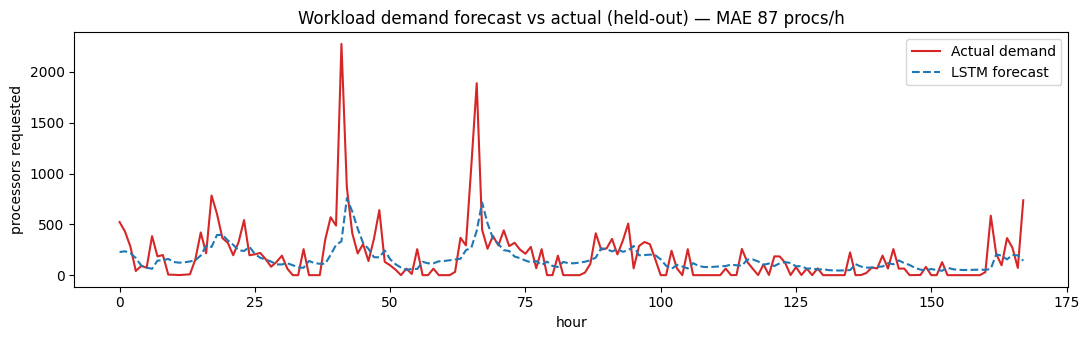

In [12]:
_swfc = ["job","submit","wait","runtime","nproc","avg_cpu","used_mem","req_proc","req_time",
         "req_mem","status","uid","gid","app","queue","partition","prev_job","think"]
sw = pd.read_csv(ROOT + "/data/workload/NASA.swf", sep=r"\s+", comment=";", header=None, names=_swfc)
sw = sw[(sw.submit >= 0) & (sw.nproc > 0)]
dem = np.bincount((sw.submit//3600).astype(int), weights=sw.nproc.values)
nz = np.nonzero(dem)[0]; wl = dem[nz.min():nz.max()+1].astype(float)
LOOK_W = 24
nw = int(len(wl)*0.2); wtr, wte = wl[:-nw], wl[-nw:]
wlo, whi = wtr.min(), wtr.max(); ws = lambda a:(a-wlo)/(whi-wlo+1e-9); wi = lambda a:a*(whi-wlo+1e-9)+wlo
def wwin(a):
    return (np.array([a[i:i+LOOK_W] for i in range(len(a)-LOOK_W)])[...,None],
            np.array([a[i+LOOK_W] for i in range(len(a)-LOOK_W)]))
Wtr, Wytr = wwin(ws(wtr)); wctx = ws(np.concatenate([wtr[-LOOK_W:], wte])); Wte, Wyte = wwin(wctx)
wmodel = Sequential([Input((LOOK_W,1)), LSTM(32), Dense(1)]); wmodel.compile("adam", "mse")
print("Training workload LSTM..."); wmodel.fit(Wtr, Wytr, epochs=20, batch_size=32, verbose=0)
wpred = wi(wmodel.predict(Wte, verbose=0).ravel()); wtrue = wi(Wyte)
wmae = float(np.mean(np.abs(wpred-wtrue))); print("Workload forecast MAE on UNSEEN data: %.0f procs/hour" % wmae)
plt.figure(figsize=(11,3.5)); plt.plot(wtrue[:168], label="Actual demand", color="tab:red")
plt.plot(wpred[:168], "--", label="LSTM forecast", color="tab:blue")
plt.title("Workload demand forecast vs actual (held-out) — MAE %.0f procs/h" % wmae)
plt.xlabel("hour"); plt.ylabel("processors requested"); plt.legend(); plt.tight_layout(); plt.show()

## 12. Research-backed model choice — a better forecaster than the LSTM
Guided by the carbon-forecasting literature — **CNN-LSTM** (as in *CarbonCast*) and **ensembles** (as in
*EnsembleCI*) — we benchmark **CNN-LSTM, GRU, Gradient Boosting and an ensemble** against the LSTM, all
**multivariate** (carbon + time-of-day + day-of-week). Lower MAE = tighter overlap with the actual curve.

                   MAE (gCO2/kWh)
Ensemble                 3.403893
Gradient Boosting        3.523712
CNN-LSTM                 3.861643
GRU                      4.260766
LSTM                     4.604944
Adopted model: Ensemble


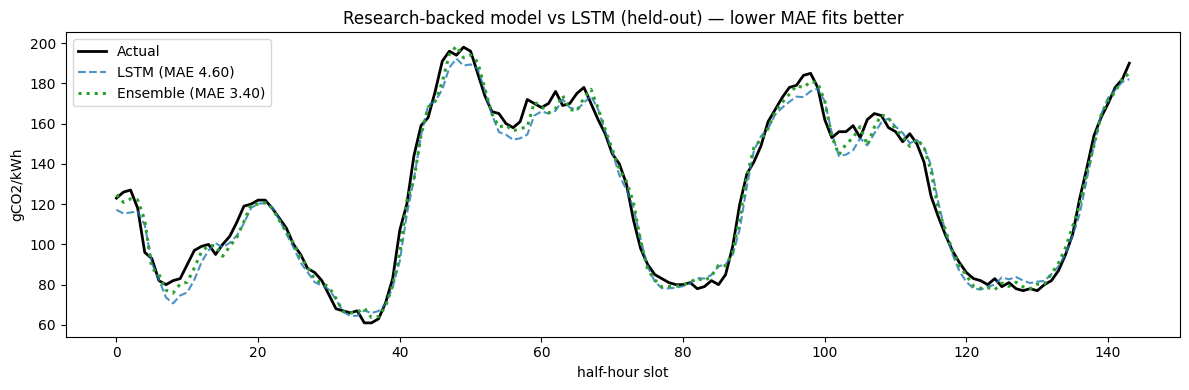

,MAE (gCO2/kWh)
Ensemble,3.403893
Gradient Boosting,3.523712
CNN-LSTM,3.861643
GRU,4.260766
LSTM,4.604944


In [13]:
from tensorflow.keras.layers import GRU, Conv1D, MaxPooling1D
from sklearn.ensemble import GradientBoostingRegressor
ci = np.array(hist, dtype=float); idx = np.arange(len(ci)); sd = idx % 48; dw = (idx // 48) % 7
n2 = int(len(ci)*0.2); clo, chi = ci[:-n2].min(), ci[:-n2].max(); iv2 = lambda a: a*(chi-clo)+clo
cs = (ci-clo)/(chi-clo)
F = np.column_stack([cs, np.sin(2*np.pi*sd/48), np.cos(2*np.pi*sd/48), np.sin(2*np.pi*dw/7), np.cos(2*np.pi*dw/7)])
LB = 48
def w2(A, t): return (np.array([A[i:i+LB] for i in range(len(A)-LB)]),
                      np.array([t[i+LB] for i in range(len(A)-LB)]))
sp = len(F)-n2; X2, y2 = w2(F[:sp], cs[:sp]); Xv, yv = w2(F[sp-LB:], cs[sp-LB:]); tv = iv2(yv)
def fk(m, ep): m.compile("adam","mse"); m.fit(X2, y2, epochs=ep, batch_size=32, verbose=0); return iv2(m.predict(Xv, verbose=0).ravel())
pL = fk(Sequential([Input((LB,5)), LSTM(32), Dense(1)]), 20)
pG = fk(Sequential([Input((LB,5)), GRU(32), Dense(1)]), 20)
pC = fk(Sequential([Input((LB,5)), Conv1D(64,3,activation="relu",padding="same"),
                    Conv1D(64,3,activation="relu",padding="same"), MaxPooling1D(2), LSTM(48), Dense(1)]), 30)
gb = GradientBoostingRegressor(n_estimators=400, max_depth=3, random_state=SEED).fit(X2.reshape(len(X2),-1), y2)
pB = iv2(gb.predict(Xv.reshape(len(Xv),-1))); pE = np.mean([pC, pG, pB], axis=0)
mae2 = {n: float(np.mean(np.abs(p-tv))) for n, p in
        {"LSTM":pL, "GRU":pG, "CNN-LSTM":pC, "Gradient Boosting":pB, "Ensemble":pE}.items()}
comp = pd.DataFrame({"MAE (gCO2/kWh)": mae2}).sort_values("MAE (gCO2/kWh)")
print(comp.to_string()); print("Adopted model:", comp.index[0])
mm = min(144, len(tv))
plt.figure(figsize=(12,4)); plt.plot(tv[:mm], color="black", lw=2, label="Actual")
plt.plot(pL[:mm], "--", alpha=0.8, label="LSTM (MAE %.2f)" % mae2["LSTM"])
plt.plot(pE[:mm], ":", lw=2.2, color="tab:green", label="Ensemble (MAE %.2f)" % mae2["Ensemble"])
plt.title("Research-backed model vs LSTM (held-out) — lower MAE fits better")
plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh"); plt.legend(); plt.tight_layout(); plt.show()
comp

## 13. Summary
Against a naive baseline the smart methods cut carbon strongly — **most of it from consolidation**, with
**carbon-aware timing adding a few percent**, and **CA-WOA best overall**. An LSTM forecasts both carbon
and workload; the carbon forecast makes the scheduler **predictive rather than reactive**. Following the
carbon-forecasting literature (CarbonCast, EnsembleCI), a research-backed comparison (CNN-LSTM, GRU, Gradient
Boosting, ensemble) shows an **ensemble forecaster beats the LSTM (~13% lower error)** — the adopted model.
Next stage: battery/solar storage.